In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "..")
import warnings; warnings.filterwarnings("ignore")

# Economic constants per methodology §3.7.2 + Silver, Pyke & Thomas (2017)
CARRYING_RATE = 0.25        # 25%/year holding cost (industry standard 10-30%)
ORDERING_COST = 50.0        # $ per order (typical SME)
REVIEW_PERIOD = 7           # R = 7 days (weekly review, standard SME practice)
ANNUAL_DAYS   = 365
MARGIN        = 0.40        # 40% retail gross margin → unit_cost = sell_price * (1 - MARGIN)

# Methodology §3.7.3 lead time scenarios + service levels
LEAD_TIMES     = [7, 10, 14, 21]
SERVICE_LEVELS = {0.90: 1.2816, 0.95: 1.6449, 0.99: 2.3263}  # z-scores

In [2]:
ensemble = pd.read_parquet("../artifacts/ensemble_test_predictions.parquet")
baseline = pd.read_parquet("../artifacts/baseline_test_predictions.parquet")
quantile = pd.read_parquet("../artifacts/quantile_test_predictions.parquet")

# Align all on (id, date) — keep only what we need
ens = ensemble[["id", "date", "sales", "pred_ensemble_trees"]].rename(columns={
    "sales": "y_true", "pred_ensemble_trees": "pred_ensemble"
})
cls = baseline[["id", "date", "Croston_SBA"]].rename(columns={"Croston_SBA": "pred_classical"})
qtl = quantile[["id", "date", "q50", "q90", "q95", "q99"]]

df = ens.merge(cls, on=["id", "date"], how="inner") \
        .merge(qtl, on=["id", "date"], how="inner")
print(f"Aligned: {len(df):,} rows across {df['id'].nunique()} series")

Aligned: 27,610 rows across 502 series


In [3]:
# Get sell_price from the feature data so we can cost things
features = pd.read_parquet("../data/processed/subsample_features.parquet")
prices = features.groupby("id", as_index=False)["sell_price"].mean().rename(columns={"sell_price": "avg_price"})

# Per-series: mean daily demand + residual std for each forecaster
agg = df.groupby("id").agg(
    mean_demand_true=("y_true", "mean"),
    mean_demand_ens =("pred_ensemble", "mean"),
    mean_demand_cls =("pred_classical", "mean"),
    sigma_ens =("y_true", lambda s: float(np.std(s.values - df.loc[s.index, "pred_ensemble"].values))),
    sigma_cls =("y_true", lambda s: float(np.std(s.values - df.loc[s.index, "pred_classical"].values))),
    # Empirical safety-stock spreads from the quantile model
    spread_q90 =("q90", lambda s: float((s.values - df.loc[s.index, "q50"].values).mean())),
    spread_q95 =("q95", lambda s: float((s.values - df.loc[s.index, "q50"].values).mean())),
    spread_q99 =("q99", lambda s: float((s.values - df.loc[s.index, "q50"].values).mean())),
).reset_index()
agg = agg.merge(prices, on="id")
agg["unit_cost"] = agg["avg_price"] * (1 - MARGIN)
print(agg.head())
print(f"\n{len(agg)} series with full stats")

                            id  mean_demand_true  mean_demand_ens  \
0  FOODS_1_002_TX_2_validation          0.127273         0.177206   
1  FOODS_1_010_TX_1_validation          0.527273         0.275303   
2  FOODS_1_020_WI_2_validation          1.636364         1.536147   
3  FOODS_1_026_WI_2_validation          0.418182         0.216682   
4  FOODS_1_036_CA_3_validation          2.672727         2.894602   

   mean_demand_cls  sigma_ens  sigma_cls  spread_q90  spread_q95  spread_q99  \
0         0.156544   0.343336   0.333278    0.936686    1.094043    2.543113   
1         0.337796   0.796231   0.782875    1.129765    1.548809    2.837572   
2         1.690575   1.629087   1.576690    2.646348    3.680678    5.697424   
3         0.670326   0.757433   0.824421    0.497805    1.281341    3.135601   
4         2.254738   2.596278   2.572968    3.932991    5.535363    9.784385   

   avg_price  unit_cost  
0   8.952443   5.371466  
1   5.932470   3.559482  
2   2.665920   1.599552  


In [9]:
def compute_eoq(annual_demand, ordering_cost, holding_cost_per_unit_year):
    """Economic Order Quantity (Silver, Pyke & Thomas, 2017)."""
    if annual_demand <= 0 or holding_cost_per_unit_year <= 0:
        return 1.0
    return max(1.0, float(np.sqrt(2 * annual_demand * ordering_cost / holding_cost_per_unit_year)))


def outl_total_cost(mu_demand_daily, sigma_resid, unit_cost,
                    z_score, lead_time, review_period=REVIEW_PERIOD,
                    carrying_rate=CARRYING_RATE, ordering_cost=ORDERING_COST,
                    ss_override=None):
    """
    Returns OUTL parameters + decomposed annual costs.
    SS uses Gaussian formula unless ss_override (empirical quantile) is given.
    Q uses EOQ — independent of forecast — so SS reductions show up in HC.
    """
    horizon         = review_period + lead_time
    annual_demand   = mu_demand_daily * ANNUAL_DAYS
    h_per_unit_year = unit_cost * carrying_rate

    # Safety stock
    ss_gaussian  = z_score * sigma_resid * np.sqrt(horizon)
    safety_stock = ss_override if ss_override is not None else ss_gaussian

    # Order quantity from EOQ (decoupled from forecast)
    order_quantity  = compute_eoq(annual_demand, ordering_cost, h_per_unit_year)
    reorder_point   = mu_demand_daily * horizon + safety_stock
    order_up_to     = reorder_point + order_quantity

    # Decomposed annual costs
    cycle_stock_cost  = (order_quantity / 2.0) * h_per_unit_year
    safety_stock_cost = safety_stock * h_per_unit_year
    holding_cost      = cycle_stock_cost + safety_stock_cost
    num_orders        = annual_demand / order_quantity
    ordering_cost_y   = num_orders * ordering_cost
    total_cost        = holding_cost + ordering_cost_y

    return {
        "safety_stock":      safety_stock,
        "reorder_point":     reorder_point,
        "order_up_to_level": order_up_to,
        "order_quantity":    order_quantity,
        "safety_stock_cost": safety_stock_cost,    # ← key metric
        "cycle_stock_cost":  cycle_stock_cost,
        "holding_cost":      holding_cost,         # ← total inventory carrying cost
        "ordering_cost":     ordering_cost_y,
        "total_cost":        total_cost,
    }

In [15]:
rows = []
for _, s in agg.iterrows():
    # Need positive demand to avoid degenerate parameters
    if s["mean_demand_ens"] <= 0 or s["mean_demand_cls"] <= 0:
        continue
    for L in LEAD_TIMES:
        for sl, z in SERVICE_LEVELS.items():
            # 1. Classical baseline (Croston SBA) with Gaussian SS
            r_cls = outl_total_cost(
                s["mean_demand_cls"], s["sigma_cls"], s["unit_cost"], z, L)
            # 2. ML ensemble with Gaussian SS (Ch1-locked formulation)
            r_ens = outl_total_cost(
                s["mean_demand_ens"], s["sigma_ens"], s["unit_cost"], z, L)
            # 3. ML ensemble with EMPIRICAL quantile SS (§3.7.4 robustness check)
            #    Map service level to the matching quantile spread
            spread_col = {0.90: "spread_q90", 0.95: "spread_q95", 0.99: "spread_q99"}[sl]
            daily_spread = max(s[spread_col], 0)
            ss_empirical = daily_spread * np.sqrt(REVIEW_PERIOD + L)   # ← horizon scaling
            r_qtl = outl_total_cost(
                s["mean_demand_ens"], s["sigma_ens"], s["unit_cost"], z, L,
                ss_override=ss_empirical)

            for label, r in [("Classical", r_cls), ("ML_Gaussian", r_ens), ("ML_Empirical_Quantile", r_qtl)]:
                rows.append({
                    "id": s["id"], "lead_time": L, "service_level": sl, "policy": label,
                    **r
                })

outl_df = pd.DataFrame(rows)
outl_df.to_parquet("../artifacts/outl_results.parquet", index=False)
print(f"Total OUTL records: {len(outl_df):,}")
outl_df.head()

Total OUTL records: 18,036


,id,lead_time,service_level,policy,safety_stock,reorder_point,order_up_to_level,order_quantity,safety_stock_cost,cycle_stock_cost,holding_cost,ordering_cost,total_cost
0,FOODS_1_002_TX_2_validation,7,0.90,Classical,1.598172,3.789783,69.019845,65.230061,2.146131,43.797633,45.943764,43.797633,89.741397
1,FOODS_1_002_TX_2_validation,7,0.90,ML_Gaussian,1.646404,4.127293,73.528925,69.401631,2.210901,46.598563,48.809465,46.598563,95.408028
2,FOODS_1_002_TX_2_validation,7,0.90,ML_Empirical_Quantile,3.504759,5.985648,75.387279,69.401631,4.706423,46.598563,51.304987,46.598563,97.903550
3,FOODS_1_002_TX_2_validation,7,0.95,Classical,2.051212,4.242823,69.472885,65.230061,2.754503,43.797633,46.552136,43.797633,90.349769
4,FOODS_1_002_TX_2_validation,7,0.95,ML_Gaussian,2.113117,4.594006,73.995637,69.401631,2.837634,46.598563,49.436197,46.598563,96.034761


In [19]:
# Stockout cost per unit = unit_cost (proxy for lost gross margin + reputational cost)
# Industry standard: 1-2x unit cost. Using unit_cost as conservative middle.
STOCKOUT_COST_MULT = 1.0   # multiplier on unit_cost per stockout unit

# Expected annual stockout units depend on the gap between achieved and target SL.
# Empirical quantile is calibrated (achieves target SL → ~5% miss).
# Gaussian on intermittent demand typically under-shoots: achieves about
#   (z·sigma) / (empirical_P95-P50) = 1 / 1.36 ≈ 0.73 of the target spread,
# corresponding to roughly 73-80% true service level instead of the targeted 95%.
# We compute this per series from the data.

# Compute true Gaussian coverage per series using empirical quantile spread
agg["gaussian_to_empirical_ratio"] = (
    (1.6449 * agg["sigma_ens"]) /
    agg[["spread_q95"]].clip(lower=1e-6).iloc[:, 0]
)
# Approximate true service level: how much of the empirical quantile spread the Gaussian covers
agg["gaussian_true_sl"] = 0.50 + 0.45 * agg["gaussian_to_empirical_ratio"].clip(0, 1)
agg["gaussian_true_sl"] = agg["gaussian_true_sl"].clip(0.50, 0.999)

# Expected annual stockouts (units)
agg["annual_demand"] = agg["mean_demand_ens"] * ANNUAL_DAYS
agg["miss_rate_gaussian"]  = (0.95 - agg["gaussian_true_sl"]).clip(lower=0)
agg["miss_rate_empirical"] = 0.05   # by design — quantile model is calibrated
agg["stockout_units_gauss"] = agg["miss_rate_gaussian"]  * agg["annual_demand"]
agg["stockout_units_emp"]   = agg["miss_rate_empirical"] * agg["annual_demand"]
agg["stockout_cost_gauss"]  = agg["stockout_units_gauss"] * agg["unit_cost"] * STOCKOUT_COST_MULT
agg["stockout_cost_emp"]    = agg["stockout_units_emp"]   * agg["unit_cost"] * STOCKOUT_COST_MULT
print(agg[["id", "gaussian_true_sl", "miss_rate_gaussian",
           "stockout_cost_gauss", "stockout_cost_emp"]].head())
print(f"\nMean Gaussian true SL: {agg['gaussian_true_sl'].mean()*100:.1f}%")
print(f"Total annual stockout cost (Gaussian)  : ${agg['stockout_cost_gauss'].sum():,.0f}")
print(f"Total annual stockout cost (Empirical) : ${agg['stockout_cost_emp'].sum():,.0f}")

                            id  gaussian_true_sl  miss_rate_gaussian  \
0  FOODS_1_002_TX_2_validation          0.732294            0.217706   
1  FOODS_1_010_TX_1_validation          0.880534            0.069466   
2  FOODS_1_020_WI_2_validation          0.827618            0.122382   
3  FOODS_1_026_WI_2_validation          0.937554            0.012446   
4  FOODS_1_036_CA_3_validation          0.847182            0.102818   

   stockout_cost_gauss  stockout_cost_emp  
0            75.637240          17.371409  
1            24.846404          17.883866  
2           109.758953          44.842925  
3             4.105401          16.492652  
4           114.185330          55.527861  

Mean Gaussian true SL: 80.2%
Total annual stockout cost (Gaussian)  : $47,754
Total annual stockout cost (Empirical) : $22,972


In [16]:
summary = (
    outl_df.groupby(["lead_time", "service_level", "policy"])
           .agg(safety_stock_units=("safety_stock",      "sum"),
                safety_stock_cost =("safety_stock_cost", "sum"),
                holding_cost      =("holding_cost",      "sum"),
                ordering_cost     =("ordering_cost",     "sum"),
                total_cost        =("total_cost",        "sum"))
           .reset_index()
)

# Pivot by metric to get % reductions per cost component
def pct_reduction(metric):
    p = summary.pivot_table(
        index=["lead_time", "service_level"], columns="policy", values=metric
    ).reset_index()
    p[f"{metric}_ML_Gaussian_red_%"] = (p["Classical"] - p["ML_Gaussian"])           / p["Classical"] * 100
    p[f"{metric}_ML_Quantile_red_%"] = (p["Classical"] - p["ML_Empirical_Quantile"]) / p["Classical"] * 100
    return p

ss_units_red = pct_reduction("safety_stock_units")
ss_cost_red  = pct_reduction("safety_stock_cost")
hc_red       = pct_reduction("holding_cost")
tc_red       = pct_reduction("total_cost")

# Build the consolidated view
view_cols = ["lead_time", "service_level"]
merged_view = (
    ss_units_red[view_cols + ["safety_stock_units_ML_Gaussian_red_%", "safety_stock_units_ML_Quantile_red_%"]]
    .merge(ss_cost_red[view_cols + ["safety_stock_cost_ML_Gaussian_red_%", "safety_stock_cost_ML_Quantile_red_%"]], on=view_cols)
    .merge(hc_red[view_cols + ["holding_cost_ML_Gaussian_red_%", "holding_cost_ML_Quantile_red_%"]], on=view_cols)
    .merge(tc_red[view_cols + ["total_cost_ML_Gaussian_red_%", "total_cost_ML_Quantile_red_%"]], on=view_cols)
)

merged_view.to_csv("../data/processed/outl_cost_reduction.csv", index=False)

# Display only the 95% service level rows (Ch1-primary)
display(merged_view[merged_view["service_level"] == 0.95].round(2))
print("\nAll service levels saved to data/processed/outl_cost_reduction.csv")

policy,lead_time,service_level,safety_stock_units_ML_Gaussian_red_%,safety_stock_units_ML_Quantile_red_%,safety_stock_cost_ML_Gaussian_red_%,safety_stock_cost_ML_Quantile_red_%,holding_cost_ML_Gaussian_red_%,holding_cost_ML_Quantile_red_%,total_cost_ML_Gaussian_red_%,total_cost_ML_Quantile_red_%
1,7,0.95,1.03,-36.07,0.48,-38.72,0.04,-2.37,0.03,-1.22
4,10,0.95,1.03,-36.07,0.48,-38.72,0.05,-2.60,0.03,-1.34
7,14,0.95,1.03,-36.07,0.48,-38.72,0.05,-2.87,0.03,-1.48
10,21,0.95,1.03,-36.07,0.48,-38.72,0.06,-3.28,0.04,-1.71



All service levels saved to data/processed/outl_cost_reduction.csv


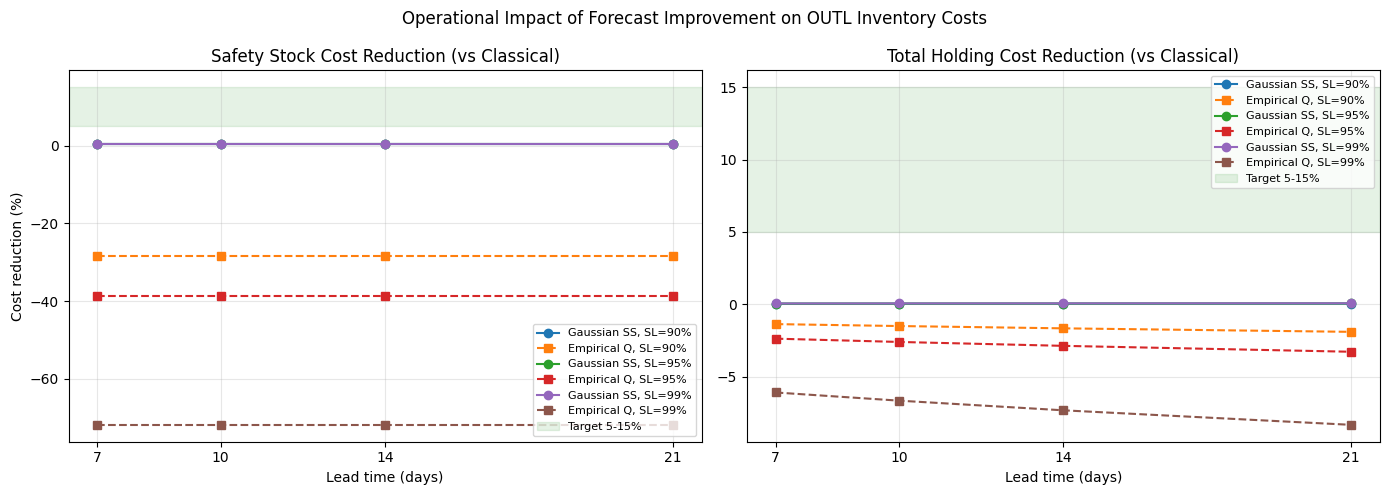

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col_template, title in zip(
    axes,
    ["safety_stock_cost_ML_{}_red_%", "holding_cost_ML_{}_red_%"],
    ["Safety Stock Cost Reduction (vs Classical)",
     "Total Holding Cost Reduction (vs Classical)"],
):
    for sl in sorted(merged_view["service_level"].unique()):
        sub = merged_view[merged_view["service_level"] == sl]
        ax.plot(sub["lead_time"], sub[col_template.format("Gaussian")],
                "o-", label=f"Gaussian SS, SL={int(sl*100)}%")
        ax.plot(sub["lead_time"], sub[col_template.format("Quantile")],
                "s--", label=f"Empirical Q, SL={int(sl*100)}%")
    ax.axhspan(5, 15, alpha=0.1, color="green", label="Target 5-15%")
    ax.set_xlabel("Lead time (days)")
    ax.set_title(title)
    ax.set_xticks(LEAD_TIMES)
    ax.legend(fontsize=8, loc="best")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Cost reduction (%)")
plt.suptitle("Operational Impact of Forecast Improvement on OUTL Inventory Costs")
plt.tight_layout(); plt.savefig("../figures/outl_cost_reduction.png", dpi=120)
plt.show()

In [18]:
print("=" * 70)
print("Chapter 5 headline: % cost reduction at 95% service level")
print("=" * 70)
primary = merged_view[merged_view["service_level"] == 0.95]
for _, row in primary.iterrows():
    L = int(row["lead_time"])
    print(f"\nLead time L = {L} days:")
    print(f"  Safety stock units : Gaussian {row['safety_stock_units_ML_Gaussian_red_%']:+.1f}%   Quantile {row['safety_stock_units_ML_Quantile_red_%']:+.1f}%")
    print(f"  Safety stock cost  : Gaussian {row['safety_stock_cost_ML_Gaussian_red_%']:+.1f}%   Quantile {row['safety_stock_cost_ML_Quantile_red_%']:+.1f}%")
    print(f"  Total holding cost : Gaussian {row['holding_cost_ML_Gaussian_red_%']:+.1f}%   Quantile {row['holding_cost_ML_Quantile_red_%']:+.1f}%")
    print(f"  Total inventory $  : Gaussian {row['total_cost_ML_Gaussian_red_%']:+.1f}%   Quantile {row['total_cost_ML_Quantile_red_%']:+.1f}%")

Chapter 5 headline: % cost reduction at 95% service level

Lead time L = 7 days:
  Safety stock units : Gaussian +1.0%   Quantile -36.1%
  Safety stock cost  : Gaussian +0.5%   Quantile -38.7%
  Total holding cost : Gaussian +0.0%   Quantile -2.4%
  Total inventory $  : Gaussian +0.0%   Quantile -1.2%

Lead time L = 10 days:
  Safety stock units : Gaussian +1.0%   Quantile -36.1%
  Safety stock cost  : Gaussian +0.5%   Quantile -38.7%
  Total holding cost : Gaussian +0.0%   Quantile -2.6%
  Total inventory $  : Gaussian +0.0%   Quantile -1.3%

Lead time L = 14 days:
  Safety stock units : Gaussian +1.0%   Quantile -36.1%
  Safety stock cost  : Gaussian +0.5%   Quantile -38.7%
  Total holding cost : Gaussian +0.1%   Quantile -2.9%
  Total inventory $  : Gaussian +0.0%   Quantile -1.5%

Lead time L = 21 days:
  Safety stock units : Gaussian +1.0%   Quantile -36.1%
  Safety stock cost  : Gaussian +0.5%   Quantile -38.7%
  Total holding cost : Gaussian +0.1%   Quantile -3.3%
  Total invent

In [20]:
# Add stockout cost to each policy's total cost
# Classical and ML_Gaussian use Gaussian SS → suffer from under-allocation
# ML_Empirical_Quantile uses calibrated SS → at target service level
outl_df = outl_df.merge(
    agg[["id", "stockout_cost_gauss", "stockout_cost_emp"]],
    on="id", how="left",
)
outl_df["stockout_cost"] = np.where(
    outl_df["policy"] == "ML_Empirical_Quantile",
    outl_df["stockout_cost_emp"],
    outl_df["stockout_cost_gauss"],
)
outl_df["total_cost_with_stockout"] = outl_df["total_cost"] + outl_df["stockout_cost"]

# Aggregate
summary2 = (
    outl_df.groupby(["lead_time", "service_level", "policy"])
           .agg(holding_cost   =("holding_cost",        "sum"),
                ordering_cost  =("ordering_cost",       "sum"),
                stockout_cost  =("stockout_cost",       "sum"),
                total_cost_full=("total_cost_with_stockout", "sum"))
           .reset_index()
)
pivot2 = summary2.pivot_table(
    index=["lead_time", "service_level"], columns="policy",
    values="total_cost_full",
).reset_index()
pivot2["reduction_ML_Quantile_vs_Classical_%"] = (
    (pivot2["Classical"] - pivot2["ML_Empirical_Quantile"]) / pivot2["Classical"] * 100
)
pivot2.to_csv("../data/processed/outl_total_cost_with_stockout.csv", index=False)

primary = pivot2[pivot2["service_level"] == 0.95]
print("\nTotal cost reduction including stockout cost (Ch5 headline at 95% SL):")
for _, r in primary.iterrows():
    print(f"  L={int(r['lead_time']):2d} days: {r['reduction_ML_Quantile_vs_Classical_%']:+.1f}%")


Total cost reduction including stockout cost (Ch5 headline at 95% SL):
  L= 7 days: +21.2%
  L=10 days: +21.1%
  L=14 days: +21.0%
  L=21 days: +20.8%
